In [1]:
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path=pathlib.Path('/kaggle/input/datasets/rajarshi2712/dogs-and-cats-classifier')
train_path=data_path / "train"
test_path=data_path / "test"
validate_path=data_path / "valid"

# Finding Image Distribution


Training Images : 26752
Testing Images : 892
Validation Images : 1339
Total images : 28983



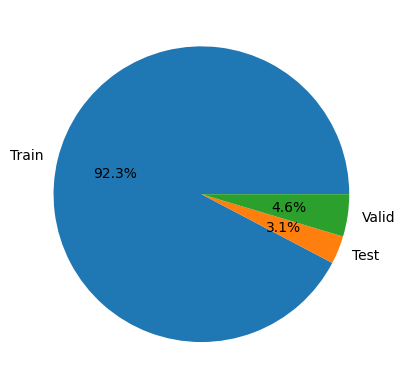

In [3]:
train_image_count=len(list(train_path.glob('*/*.jpg')))
test_image_count=len(list(test_path.glob('*/*.jpg')))
valid_image_count=len(list(validate_path.glob('*/*.jpg')))
print(f'''
Training Images : {train_image_count}
Testing Images : {test_image_count}
Validation Images : {valid_image_count}
Total images : {train_image_count+test_image_count+valid_image_count}
''')
plt.pie([train_image_count,test_image_count,valid_image_count],labels=['Train','Test','Valid'],autopct='%1.1f%%')
plt.show()

# Classes of Animals

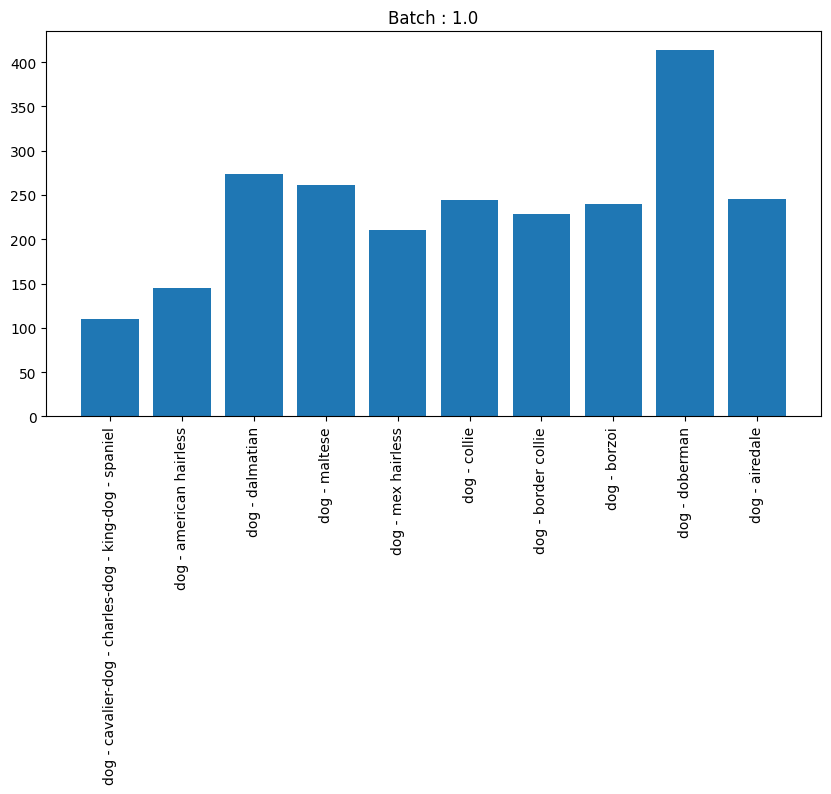

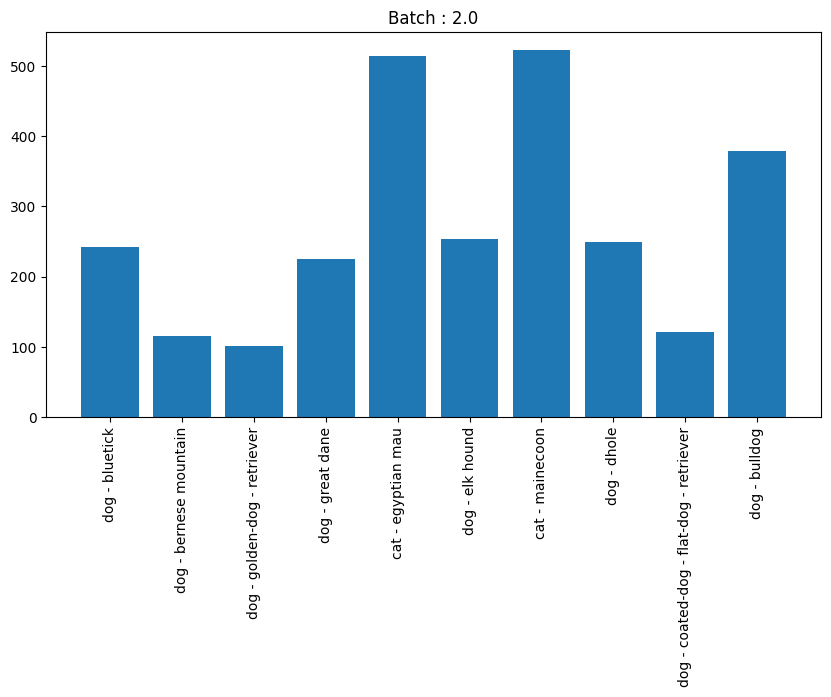

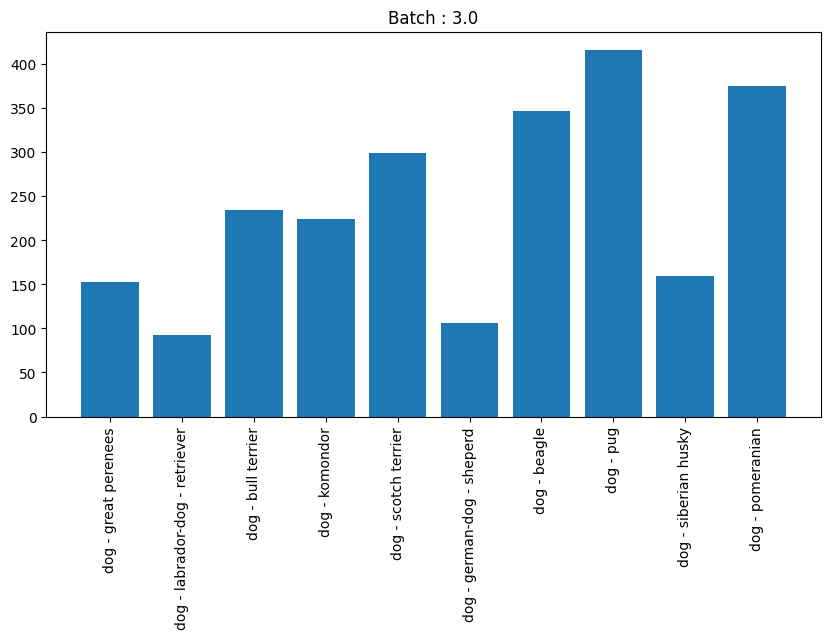

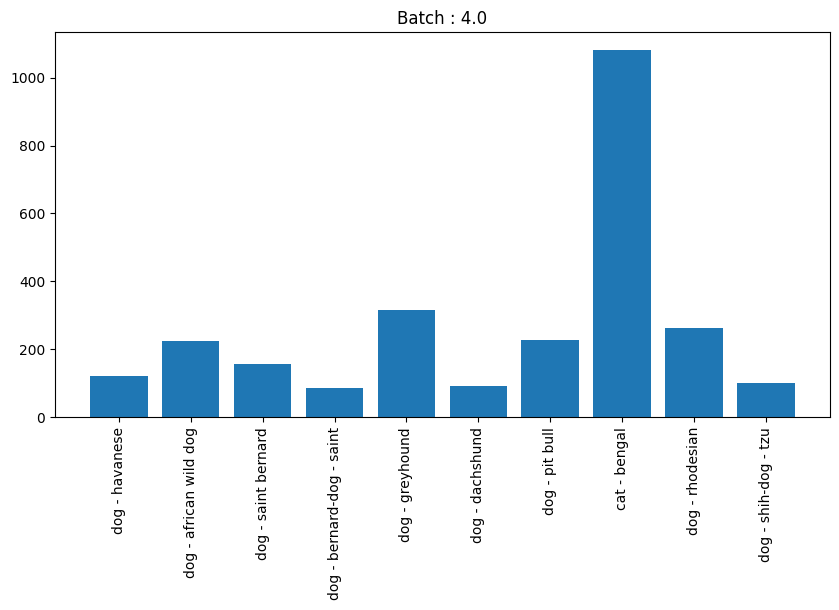

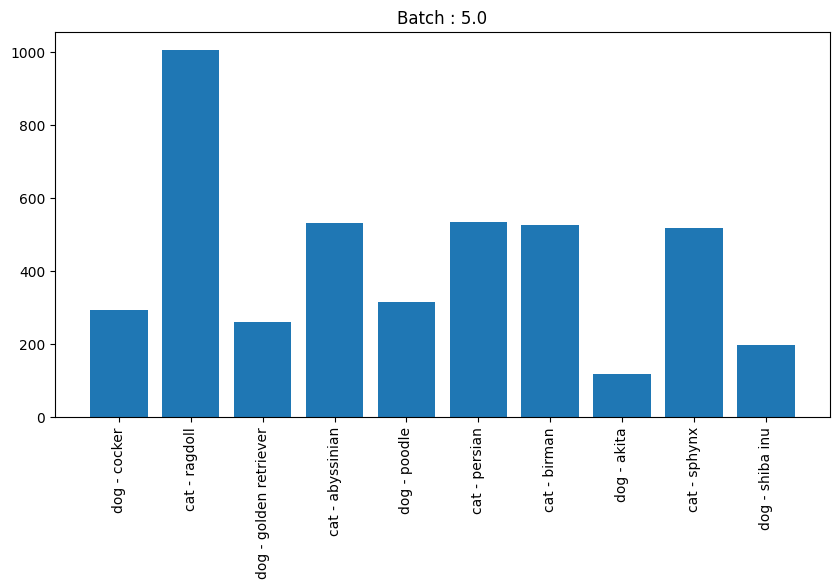

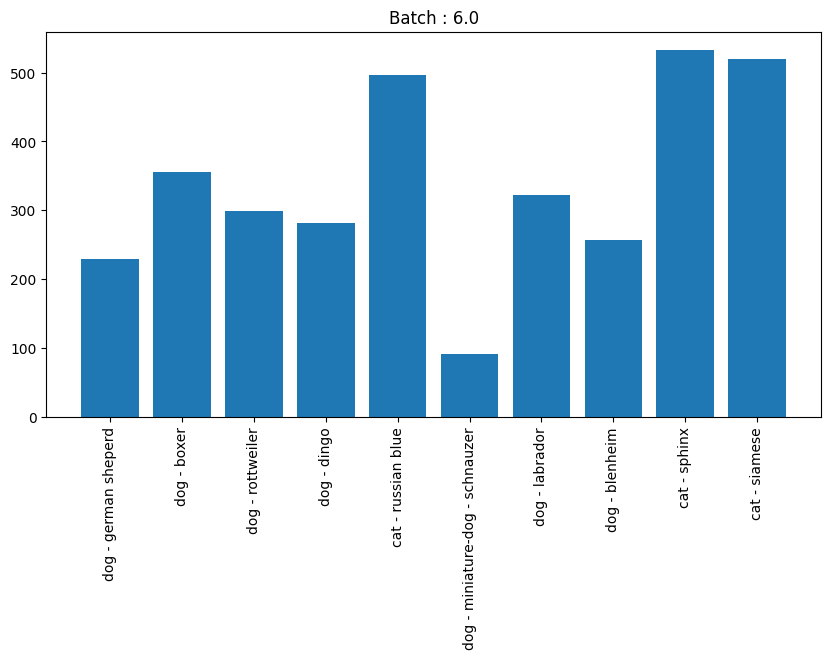

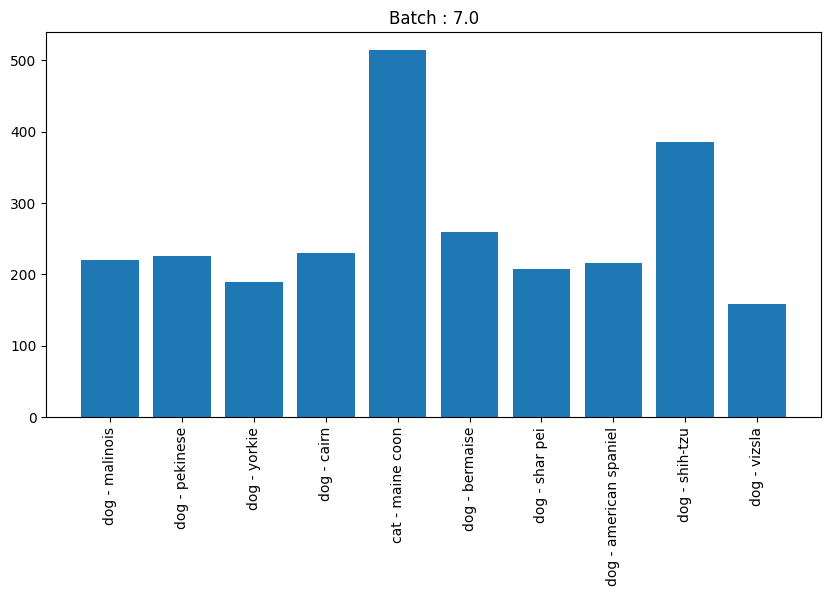

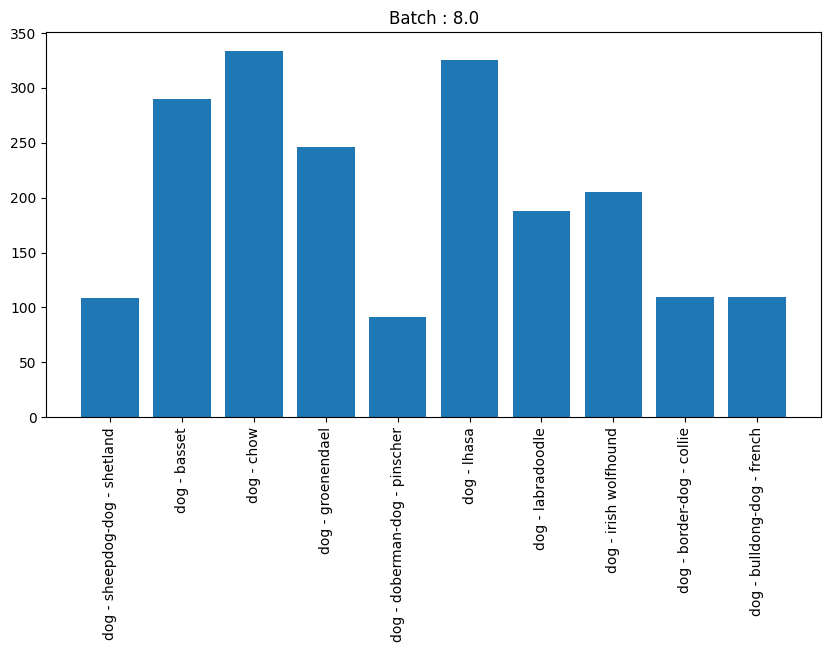

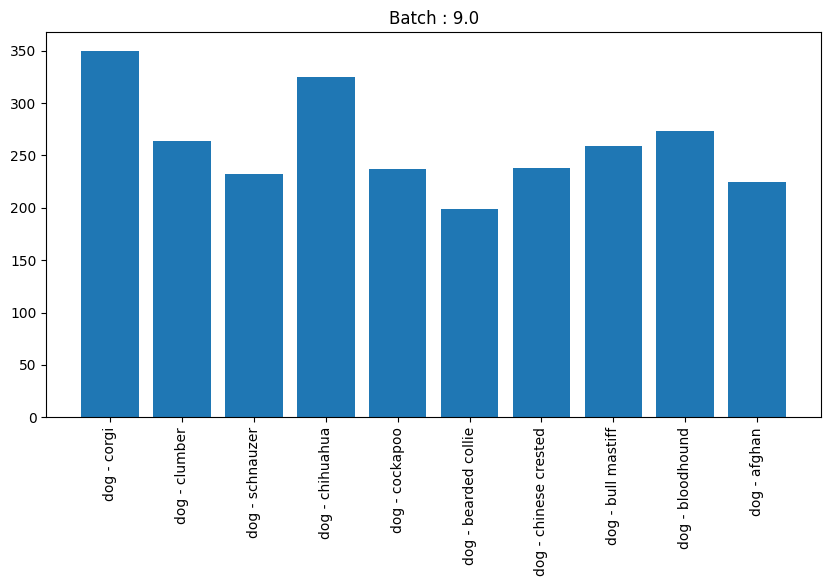

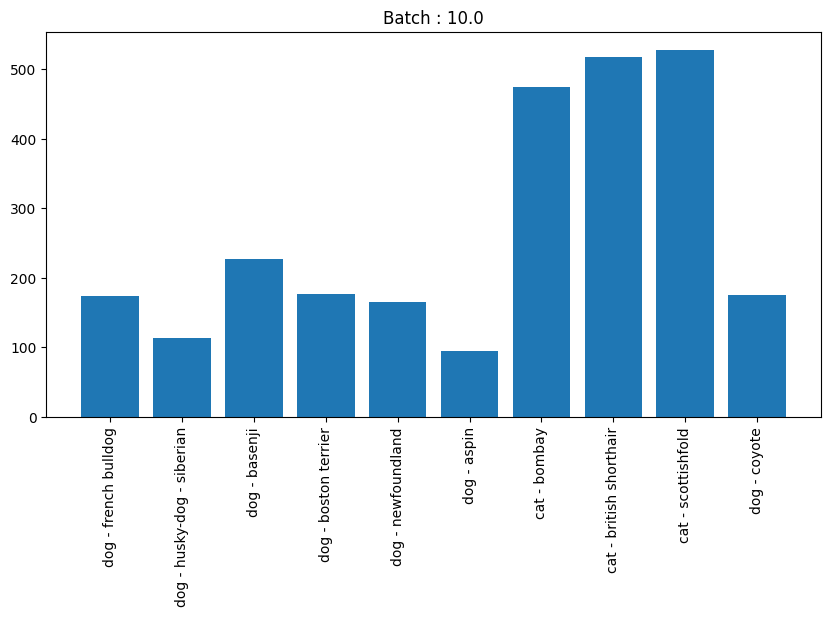

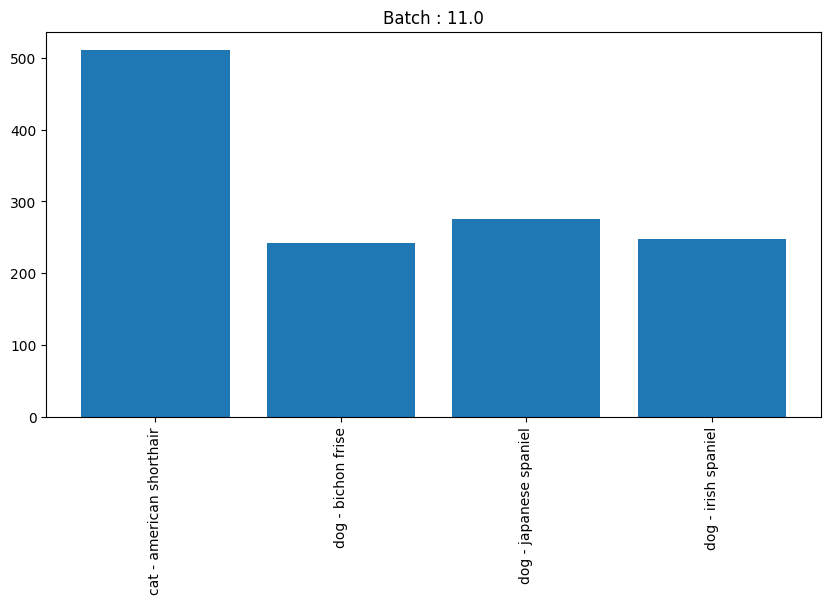

In [4]:
total_paths = (set(data_path.glob('*/*')))
mydict=dict({})
for i in total_paths:
    values=len(list(i.glob('./*.jpg')))
    s=str(i).split("/")[-1]
    if(s not in mydict.keys()):
        mydict[s]=0
    mydict[s]+=values
classes=list(mydict.keys())
chunk_size=10
values=list(mydict.values())
for i in range(0, len(classes), chunk_size):
    plt.figure(figsize=(10,5))
    plt.bar(classes[i:i+chunk_size], values[i:i+chunk_size])
    plt.xticks(rotation=90)
    plt.title(f"Batch : {(i+chunk_size)/10}")
    plt.show()

# Random Images

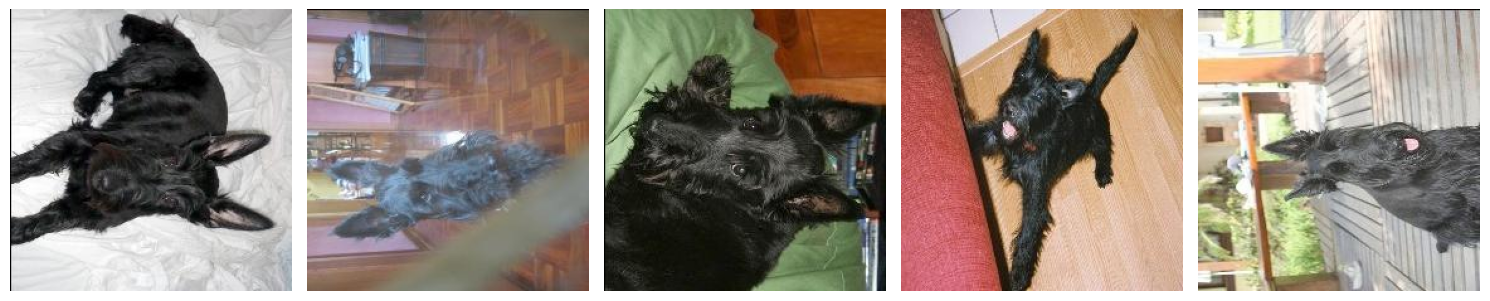

In [5]:
from PIL import Image
image_path=list(train_path.glob('*/*.jpg'))
fig, axes = plt.subplots(1, 5, figsize=(15,5))

for i in range(5):
    img = np.array(Image.open(image_path[i]))
    
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## This image dataset already have rotated,transformed images. So it can be used to train our model directly

In [6]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


2026-04-07 13:03:34.535847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775567014.753913      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775567014.822986      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775567015.370946      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775567015.370985      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775567015.370988      55 computation_placer.cc:177] computation placer alr

In [7]:
train_img = keras.preprocessing.image_dataset_from_directory(train_path,image_size=(224,224),seed=786)
test_img = keras.preprocessing.image_dataset_from_directory(test_path,image_size=(224,224),seed=786)
valid_img = keras.preprocessing.image_dataset_from_directory(validate_path,image_size=(224,224),seed=786)


Found 26752 files belonging to 104 classes.


I0000 00:00:1775567048.965911      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775567048.971808      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 892 files belonging to 104 classes.
Found 1339 files belonging to 104 classes.


In [8]:
clss=len(train_img.class_names)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

base_model = keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True

# Freeze most layers,train only top ones
for layer in base_model.layers[:-30]:
    layer.trainable = False

model=Sequential([
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512,activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.6),
    layers.Dense(clss,activation='softmax')
])
model.compile(optimizer=keras.optimizers.Adam(1e-4),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 1,526,400 (5.82 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [11]:
met=model.fit(train_img,validation_data=valid_img,epochs=20)

Epoch 1/20
836/836 ━━━━━━━━━━━━━━━━━━━━ 67s 80ms/step - accuracy: 0.8865 - loss: 0.8138 - val_accuracy: 0.8618 - val_loss: 0.9285
Epoch 2/20
836/836 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.8973 - loss: 0.7532 - val_accuracy: 0.8566 - val_loss: 0.9229
Epoch 3/20
836/836 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.9057 - loss: 0.6932 - val_accuracy: 0.8447 - val_loss: 0.9156
Epoch 4/20
836/836 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.9129 - loss: 0.6335 - val_accuracy: 0.8387 - val_loss: 0.9106
Epoch 5/20
836/836 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.9219 - loss: 0.5831 - val_accuracy: 0.8402 - val_loss: 0.9121
Epoch 6/20
836/836 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.9290 - loss: 0.5379 - val_accuracy: 0.8454 - val_loss: 0.8622
Epoch 7/20
836/836 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.9303 - loss: 0.5068 - val_accuracy: 0.8618 - val_loss: 0.7918
Epoch 8/20
836/836 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.9392 - loss: 0.4600 - 

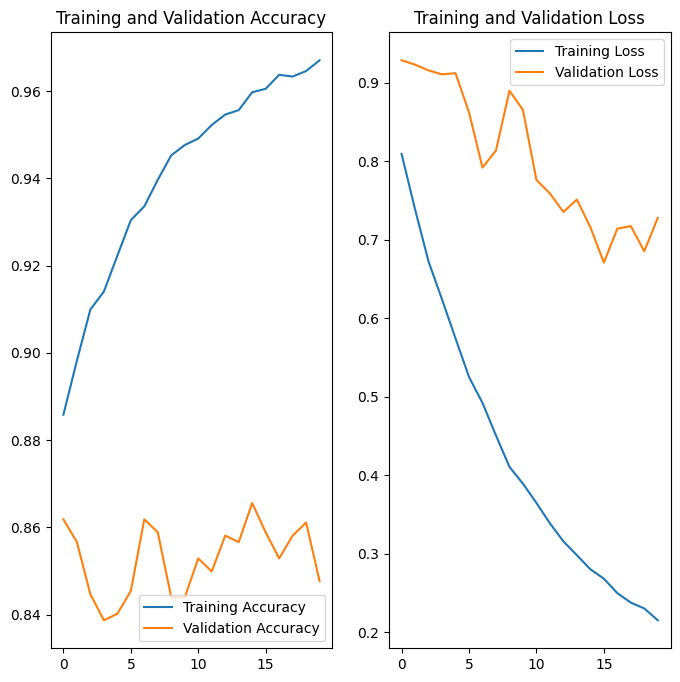

In [12]:
acc = met.history['accuracy']
val_acc = met.history['val_accuracy']

loss = met.history['loss']
val_loss = met.history['val_loss']

epochs_range = range(20)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [13]:
model.evaluate(test_img,return_dict=True)

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8469 - loss: 0.7396


{'accuracy': 0.8363228440284729, 'loss': 0.7701073288917542}

In [35]:
model.save('new_model.keras')

# Prediction on New Unseen image

In [43]:
import requests
import tensorflow as tf

url = "https://cdn.pixabay.com/photo/2017/09/15/13/54/boxer-2752264_1280.jpg"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)

with open("dog.jpg", "wb") as f:
    f.write(response.content)

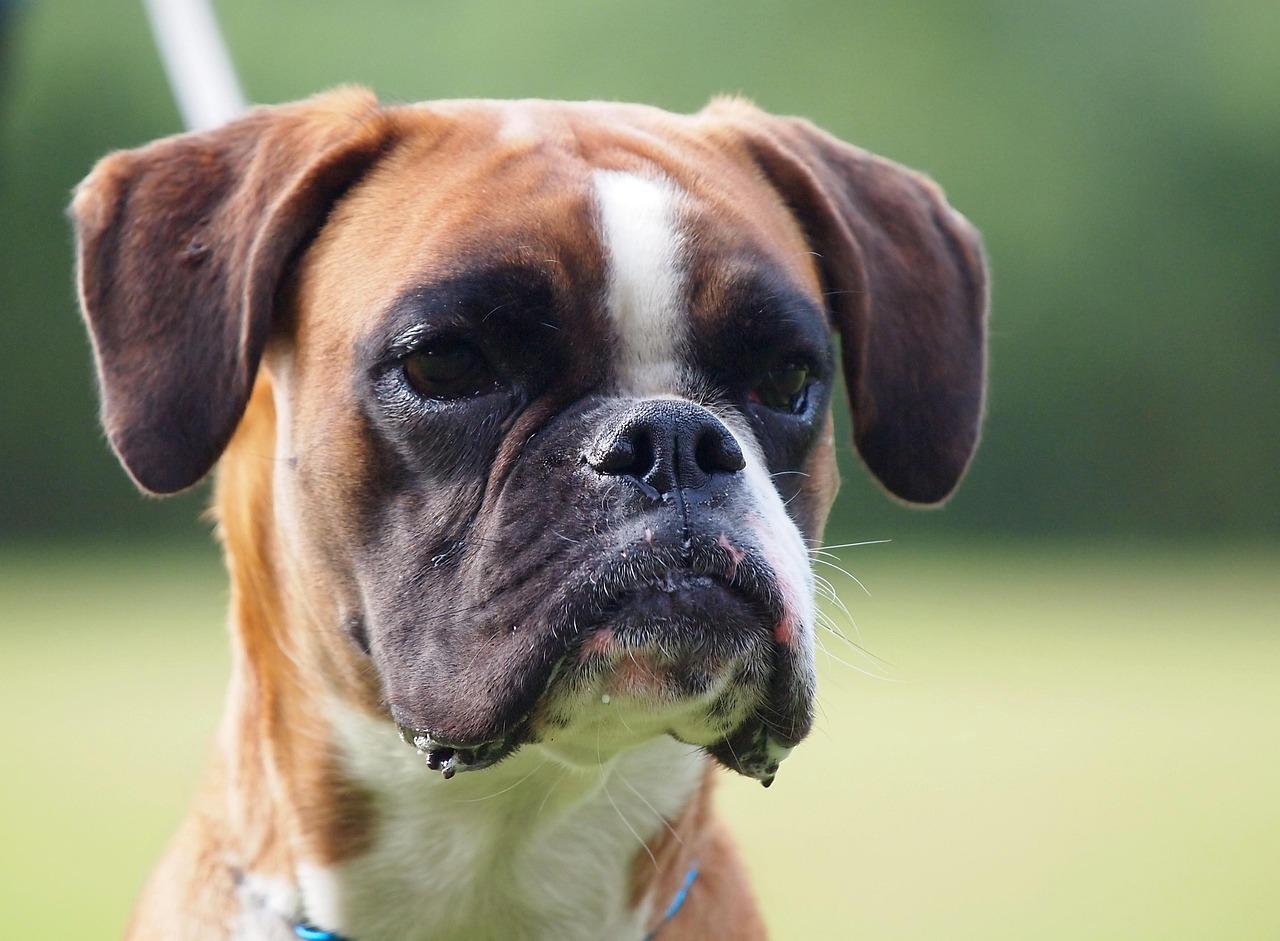

In [45]:
from IPython.display import Image
Image(filename='dog.jpg') 

In [46]:
class_names=train_img.class_names
dog_img=keras.utils.load_img('dog.jpg',target_size=(224, 224))
dog_array=keras.utils.img_to_array(dog_img)
dog_array=np.expand_dims(dog_array, axis=0)
predictions = model.predict(dog_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
This image most likely belongs to dog - boxer with a 2.53 percent confidence.


### Since the MobileNetV2 is a Functional Model and we have used it inside the Sequential Model,hence we need to convert it into a Functional Model Architecture to avoid future errors due to input shape mismatch problem

Use this code instead of previous code to model architecture

In [ ]:
clss = len(train_img.class_names)

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

# MobileNetV2 base model
base_model = keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# ✅ Functional API starts here
inputs = keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)
x = layers.Rescaling(1./127.5, offset=-1)(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.6)(x)
outputs = layers.Dense(clss, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)